In [9]:
from utils import *

import numpy as np
from sklearn.mixture import GaussianMixture
from collections import defaultdict
from sklearn.cluster import DBSCAN
from math import sqrt
from scipy.stats import norm

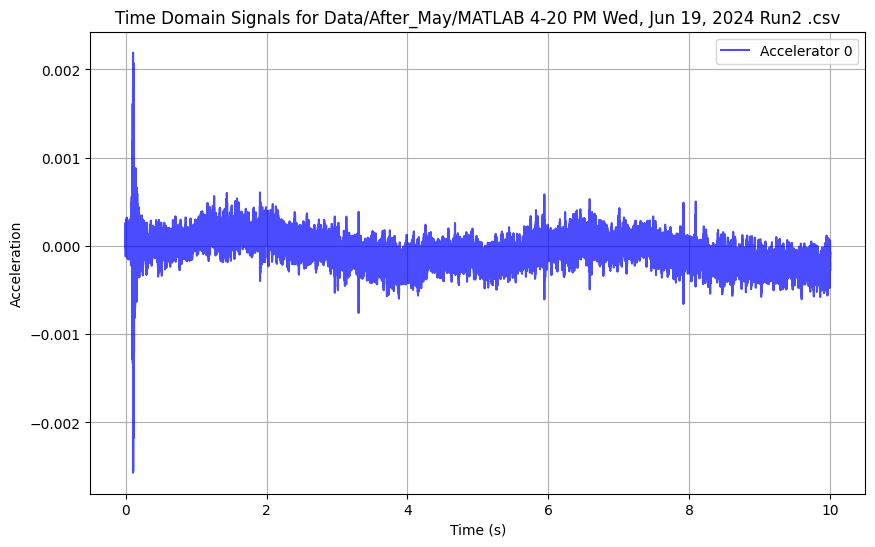

In [10]:
file = 'Data/After_May/MATLAB 4-20 PM Wed, Jun 19, 2024 Run2 .csv'
# file = 'Data/After_May/MATLAB 1-00 PM Fri, Jun 28, 2024 Run8 .csv'
# file = 'Data/After_May/MATLAB 1-51 PM Tue, Oct 29, 2024 Run13 .csv'
# file = 'Data/After_May/MATLAB 2-45 PM Thu, Oct 24, 2024 Run10 .csv'
# file = 'Data/After_May/MATLAB 1-25 PM Thu, Nov 7, 2024 Run11 .csv'
# file = 'Data/After_May/MATLAB 2-21 PM Mon, Oct 28, 2024 Run4 .csv'
# file = 'Data/After_May/MATLAB 2-47 PM Mon, Oct 28, 2024 Run10 .csv'
# file = 'Data/After_May/MATLAB 1-36 PM Thu, Nov 7, 2024 Run14 .csv'
# file = 'Data/After_May/MATLAB 1-38 PM Thu, Nov 7, 2024 Run15 .csv'
acceleration0 = get_file(file)
x, _ = get_peaks(acceleration0)

plot_file(file)

In [11]:
# Calculate all time differences (at most max_diff apart)

def get_diffs(x):
    min_tries = 3
    max_allowed_diff = (x[-1] - x[0]) / 2
    max_diff = (x[-1] - x[0]) / (min_tries - 1)  # e.g., 3 tries = 2 intervals

    # Use the tighter of the two constraints
    cutoff = min(max_diff, max_allowed_diff)

    diffs = []
    for i in range(len(x) - 1):
        for j in range(i + 1, len(x)):
            d = float(x[j] - x[i])
            if d > cutoff:
                break  # since x is sorted, all future j will be worse
            diffs.append(d)

    return sorted(diffs)


diffs = get_diffs(x)
[round(x, 5) for x in diffs]

IndexError: index -1 is out of bounds for axis 0 with size 0

In [340]:
# Choose a clustering method, cluster diffs, summarize each cluster

def dbscan_clustering(diffs, eps=0.005, min_samples=5):
    diffs = np.array(diffs).reshape(-1, 1)
    db = DBSCAN(eps=eps, min_samples=min_samples).fit(diffs)
    labels = db.labels_

    clusters = {}
    for id, label in enumerate(sorted(set(labels))):
        if label == -1:
            continue  # skip noise
        group = diffs[labels == label].flatten()
        if len(group) >= 2:
            clusters[id] = ({
                'mean': np.mean(group),
                'sd': np.std(group),
                'n': len(group)
            })

    return clusters


def pmm_clustering(diffs, random_state=0):
    """
    Performs GMM clustering on diffs and returns a dictionary of clusters sorted by mean.
    Each cluster is represented as a dictionary with keys:
    - 'mean': mean of the cluster
    - 'sd': standard deviation of the cluster
    - 'n': number of points in the cluster
    """
    min_components = 1
    max_components = min(50, max(2, len(diffs) // 5))
    print(f"Trying up to {max_components} components")

    X = np.array(diffs).reshape(-1, 1)
    bics, models = [], []

    for k in range(min_components, max_components + 1):
        model = GaussianMixture(n_components=k, random_state=random_state).fit(X)
        bics.append(model.bic(X))
        models.append(model)

    # Select best model
    best_index = np.argmin(bics)
    best_model = models[best_index]
    labels = best_model.predict(X)

    # Group values by cluster label
    cluster_data = defaultdict(list)
    for val, label in zip(diffs, labels):
        cluster_data[label].append(val)

    # Summarize and sort clusters by mean
    raw_clusters = []
    for values in cluster_data.values():
        values = np.array(values)
        if len(values) < 2:
            continue
        raw_clusters.append({
            'mean': np.mean(values),
            'sd': np.std(values),
            'n': len(values)
        })

    raw_clusters.sort(key=lambda x: x['mean'])

    # Build final result
    clusters = {
        i: {
            'mean': np.float64(c['mean']),
            'sd': np.float64(c['sd']),
            'n': int(c['n'])
        } for i, c in enumerate(raw_clusters)
    }

    return clusters


# clusters = dbscan_clustering(diffs)
clusters = pmm_clustering(diffs)
clusters

Trying up to 30 components


{0: {'mean': np.float64(0.23581000000000002),
  'sd': np.float64(0.0009449338601193527),
  'n': 20},
 1: {'mean': np.float64(0.47157368421052626),
  'sd': np.float64(0.001261512085706015),
  'n': 19},
 2: {'mean': np.float64(0.7072833333333333),
  'sd': np.float64(0.0018010028070803005),
  'n': 18},
 3: {'mean': np.float64(0.942935294117647),
  'sd': np.float64(0.0021614105352130587),
  'n': 17},
 4: {'mean': np.float64(1.1785437499999998),
  'sd': np.float64(0.0024415591202139155),
  'n': 16},
 5: {'mean': np.float64(1.4142333333333332),
  'sd': np.float64(0.002559340192749292),
  'n': 15},
 6: {'mean': np.float64(1.6498142857142855),
  'sd': np.float64(0.002719468735632307),
  'n': 14},
 7: {'mean': np.float64(1.8855307692307695),
  'sd': np.float64(0.0026996822079031076),
  'n': 13},
 8: {'mean': np.float64(2.1211583333333333),
  'sd': np.float64(0.002828267530171472),
  'n': 12},
 9: {'mean': np.float64(2.3547714285714285),
  'sd': np.float64(0.001120859728338983),
  'n': 7}}

In [341]:
# Count number of hits each cluster has

def count_hits_with_optimal_start(
    x, delta_t, sd, n, confidence=0.95, max_starts=10, extra_margin=0.00405
):
    import numpy as np
    from scipy.stats import norm

    x = np.array(x)
    se = sd / np.sqrt(n)
    z = norm.ppf(1 - (1 - confidence) / 2)
    margin = z * se + extra_margin

    best_hits = []
    best_tries = 0
    best_anchor = x[0]

    for i in range(min(max_starts, len(x))):
        anchor = x[i]
        hit_indices = []
        tries = 0
        last_hit = anchor

        while True:
            t = last_hit + delta_t
            if t > x[-1]:
                break

            # Check for hit within margin
            candidates = np.where((x >= t - margin) & (x <= t + margin))[0]
            if candidates.size > 0:
                hit_idx = candidates[0]
                hit_indices.append(hit_idx)
                last_hit = x[hit_idx]  # Recenter from hit
            else:
                last_hit = t  # No hit — continue from expected

            tries += 1

        if len(hit_indices) > len(best_hits):
            best_hits = hit_indices
            best_tries = tries
            best_anchor = anchor

    return delta_t, best_anchor, len(best_hits), best_tries


def add_hit_data(clusters):
    for id, cluster in clusters.items():
        delta_t, anchor, hits, tries = count_hits_with_optimal_start(x, cluster["mean"], cluster["sd"], cluster["n"])
        cluster["anchor"] = anchor
        cluster["hits"] = hits
        cluster["tries"] = tries
    return clusters

clusters = add_hit_data(clusters)
clusters

{0: {'mean': np.float64(0.23581000000000002),
  'sd': np.float64(0.0009449338601193527),
  'n': 20,
  'anchor': np.float64(0.1035),
  'hits': 20,
  'tries': 20},
 1: {'mean': np.float64(0.47157368421052626),
  'sd': np.float64(0.001261512085706015),
  'n': 19,
  'anchor': np.float64(0.1035),
  'hits': 10,
  'tries': 10},
 2: {'mean': np.float64(0.7072833333333333),
  'sd': np.float64(0.0018010028070803005),
  'n': 18,
  'anchor': np.float64(0.1035),
  'hits': 6,
  'tries': 6},
 3: {'mean': np.float64(0.942935294117647),
  'sd': np.float64(0.0021614105352130587),
  'n': 17,
  'anchor': np.float64(0.1035),
  'hits': 5,
  'tries': 5},
 4: {'mean': np.float64(1.1785437499999998),
  'sd': np.float64(0.0024415591202139155),
  'n': 16,
  'anchor': np.float64(0.1035),
  'hits': 3,
  'tries': 4},
 5: {'mean': np.float64(1.4142333333333332),
  'sd': np.float64(0.002559340192749292),
  'n': 15,
  'anchor': np.float64(0.1035),
  'hits': 3,
  'tries': 3},
 6: {'mean': np.float64(1.6498142857142855)

In [342]:
# Filter out insufficient hits (based on binomial distribution)

from scipy.stats import binomtest

def filter_delta_ts(hit_data, alpha=0.05, p_null=0.3):
    # [print(binomtest(v["hits"], v["tries"], p_null, alternative="greater").pvalue, v["hits"], v["tries"]) for k, v in hit_data.items()]
    return {
        k: v for k, v in hit_data.items()
        if binomtest(v["hits"], v["tries"], p_null, alternative="greater").pvalue < alpha
    }

filtered_clusters = filter_delta_ts(clusters)
filtered_clusters

{0: {'mean': np.float64(0.23581000000000002),
  'sd': np.float64(0.0009449338601193527),
  'n': 20,
  'anchor': np.float64(0.1035),
  'hits': 20,
  'tries': 20},
 1: {'mean': np.float64(0.47157368421052626),
  'sd': np.float64(0.001261512085706015),
  'n': 19,
  'anchor': np.float64(0.1035),
  'hits': 10,
  'tries': 10},
 2: {'mean': np.float64(0.7072833333333333),
  'sd': np.float64(0.0018010028070803005),
  'n': 18,
  'anchor': np.float64(0.1035),
  'hits': 6,
  'tries': 6},
 3: {'mean': np.float64(0.942935294117647),
  'sd': np.float64(0.0021614105352130587),
  'n': 17,
  'anchor': np.float64(0.1035),
  'hits': 5,
  'tries': 5},
 5: {'mean': np.float64(1.4142333333333332),
  'sd': np.float64(0.002559340192749292),
  'n': 15,
  'anchor': np.float64(0.1035),
  'hits': 3,
  'tries': 3}}

In [12]:
# Remove all integetr multiples of lower frequencies

def prob_integer_multiple(base, sd_base, n_base, candidate, sd_candidate, n_candidate):
    """
    Computes the probability that the candidate mean is an integer multiple of the base mean,
    using propagated standard error.

    Parameters:
    - base, sd_base, n_base: mean, std, and sample size of base cluster
    - candidate, sd_candidate, n_candidate: same for candidate cluster

    Returns:
    - best_k: closest integer multiple
    - probability: two-tailed probability that ratio ≈ k
    """
    ratio = candidate / base
    best_k = round(ratio)

    # Use standard error (not just std dev)
    se_base = sd_base / sqrt(n_base)
    se_candidate = sd_candidate / sqrt(n_candidate)

    # Error propagation for ratio
    ratio_se = ratio * sqrt((se_candidate / candidate)**2 + (se_base / base)**2)

    z = abs(ratio - best_k) / ratio_se
    probability = 2 * (1 - norm.cdf(z))  # two-tailed

    return probability


def remove_integer_multiples(clusters_dict, p_thresh=0.05):
    cluster_ids = list(clusters_dict.keys())
    keep = {cid: True for cid in cluster_ids}

    for i in range(len(cluster_ids) - 1):
        ci_id = cluster_ids[i]
        if not keep[ci_id]:
            continue
        for j in range(i + 1, len(cluster_ids)):
            cj_id = cluster_ids[j]
            if not keep[cj_id]:
                continue

            ci = clusters_dict[ci_id]
            cj = clusters_dict[cj_id]

            p = prob_integer_multiple(
                base=ci["mean"], sd_base=ci["sd"], n_base=ci["n"],
                candidate=cj["mean"], sd_candidate=cj["sd"], n_candidate=cj["n"]
            )

            if p > p_thresh:
                keep[cj_id] = False

    # Return a new dictionary with only the clusters to keep
    pruned = {cid: clusters_dict[cid] for cid in cluster_ids if keep[cid]}
    return pruned

base_diffs = remove_integer_multiples(filtered_clusters)
base_diffs

NameError: name 'filtered_clusters' is not defined

In [344]:
# Extract number of base_diffs and mean of each base diff

# def extract_means(base_diffs):
#     cluster_0_mean = base_diffs[0]["mean"] if 0 in base_diffs else 0
#     cluster_1_mean = base_diffs[1]["mean"] if 1 in base_diffs else 0
#     cluster_2_mean = base_diffs[2]["mean"] if 2 in base_diffs else 0
#     return [float(cluster_0_mean), float(cluster_1_mean), float(cluster_2_mean)]
#
#
# result = extract_means(base_diffs)
# result

[0.23581000000000002, 0.0, 0.0]

In [13]:
# def multiple_boilings(peaks):
#     diffs = get_diffs(peaks)
#     clusters = pmm_clustering(diffs)
#     clusters = add_hit_data(clusters)
#     filtered_clusters = filter_delta_ts(clusters)
#     base_diffs = remove_integer_multiples(filtered_clusters)
#     result = extract_means(base_diffs)
#     return result

def number_of_boilings(peaks):
    diffs = get_diffs(peaks)
    clusters = pmm_clustering(diffs)
    clusters = add_hit_data(clusters)
    filtered_clusters = filter_delta_ts(clusters)
    base_diffs = remove_integer_multiples(filtered_clusters)
    return len(base_diffs)

number_of_boilings(x)

IndexError: index -1 is out of bounds for axis 0 with size 0